<a href="https://colab.research.google.com/github/ODARI-CHARLES1/titanic_ml_prediction/blob/main/Titanic_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic - Machine Learning from Disaster

## Imports

In [ ]:
pip install opendatasets --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import opendatasets as od
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")

## Dataset

In [ ]:
data_url="https://www.kaggle.com/competitions/titanic/data"
od.download(data_url)

Skipping, found downloaded files in "./titanic" (use force=True to force download)


In [ ]:
test_data=pd.read_csv("/content/titanic/test.csv")
train_data=pd.read_csv("/content/titanic/train.csv")

In [ ]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Preprocessing Data

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
#drop name and passenger id for training id
train_data.drop(["Name","PassengerId"],axis=1,inplace=True)

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    object 
 7   Fare      891 non-null    float64
 8   Cabin     204 non-null    object 
 9   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 69.7+ KB


In [ ]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
train_data.Cabin.unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [ ]:
train_data.Embarked.unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [ ]:
train_data.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687
Embarked,2


In [ ]:
#Fill nan values of age with median .
train_data.Age.fillna(train_data.Age.median(),inplace=True)

In [ ]:
train_data.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687
Embarked,2


In [ ]:
#drop cabin column
train_data.drop("Cabin",axis=1,inplace=True)

In [ ]:
train_data.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,2


In [ ]:
train_data.dropna(inplace=True)

In [ ]:
train_data.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,0


In [ ]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_pipeline, ['Age', 'Fare', 'SibSp', 'Parch']),
    ('cat', cat_pipeline, ['Pclass', 'Sex', 'Embarked'])
])

### splitting data

In [ ]:
features=['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Sex', 'Embarked']
target=['Survived']
X=train_data[features]
y=train_data[target]

In [ ]:
X.head()

,Age,Fare,SibSp,Parch,Pclass,Sex,Embarked
0,22.0,7.2500,1,0,3,male,S
1,38.0,71.2833,1,0,1,female,C
2,26.0,7.9250,0,0,3,female,S
3,35.0,53.1000,1,0,1,female,S
4,35.0,8.0500,0,0,3,male,S


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

## scaling and encoding data

In [ ]:
target=train_data.Survived
train_data.drop("Survived",axis=1,inplace=True)
X=train_data
y=target

In [ ]:
categorical_cols=["Sex","Embarked"]
numerical_cols=["Pclass","Age","SibSp","Parch","Fare"]

In [ ]:
train_data[numerical_cols]
scaler=StandardScaler()
def normalize(numerical_cols):
  for each in numerical_cols:
    train_data[each]=scaler.fit_transform(train_data[[each]])
normalize(numerical_cols)

In [ ]:
train_data[numerical_cols]

,Pclass,Age,SibSp,Parch,Fare
0,0.825209,-0.563674,0.431350,-0.474326,-0.500240
1,-1.572211,0.669217,0.431350,-0.474326,0.788947
2,0.825209,-0.255451,-0.475199,-0.474326,-0.486650
3,-1.572211,0.438050,0.431350,-0.474326,0.422861
4,0.825209,0.438050,-0.475199,-0.474326,-0.484133
...,...,...,...,...,...
886,-0.373501,-0.178396,-0.475199,-0.474326,-0.384475
887,-1.572211,-0.794841,-0.475199,-0.474326,-0.042213
888,0.825209,-0.101340,0.431350,2.006119,-0.174084
889,-1.572211,-0.255451,-0.475199,-0.474326,-0.042213


In [ ]:
train_data[categorical_cols]

,Sex,Embarked
0,male,S
1,female,C
2,female,S
3,female,S
4,male,S
...,...,...
886,male,S
887,female,S
888,female,S
889,male,C


## Visualisation

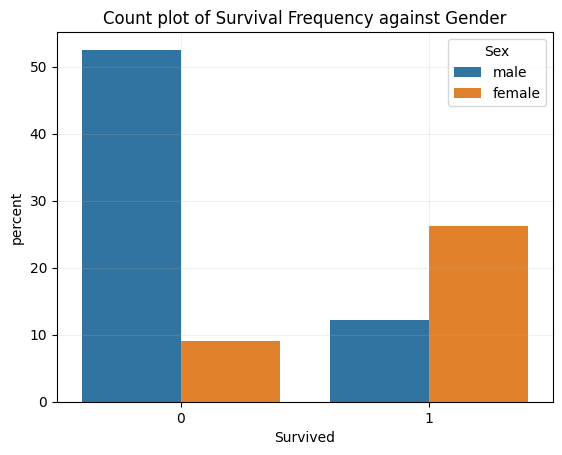

In [ ]:
sns.countplot(train_data,x='Survived',hue='Sex',stat="percent")
plt.title("Count plot of Survival Frequency against Gender")
plt.grid(True, which='major', linestyle='-',alpha=0.2)
plt.show();

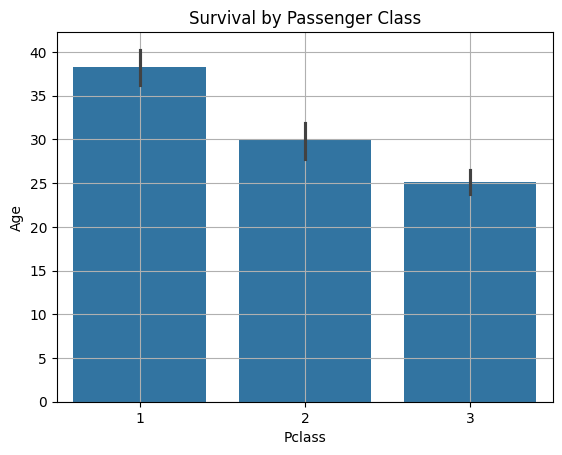

In [ ]:
sns.barplot(x='Pclass', y='Age', data=train_data)
plt.title("Survival by Passenger Class")
plt.grid(True)
plt.show()

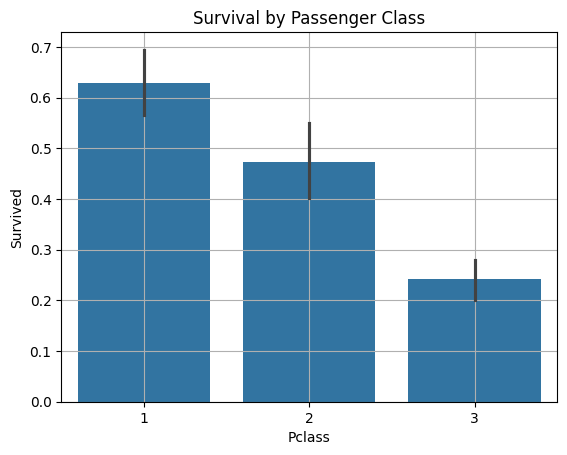

In [ ]:
sns.barplot(x='Pclass', y='Survived', data=train_data)
plt.title("Survival by Passenger Class")
plt.grid(True)
plt.show()

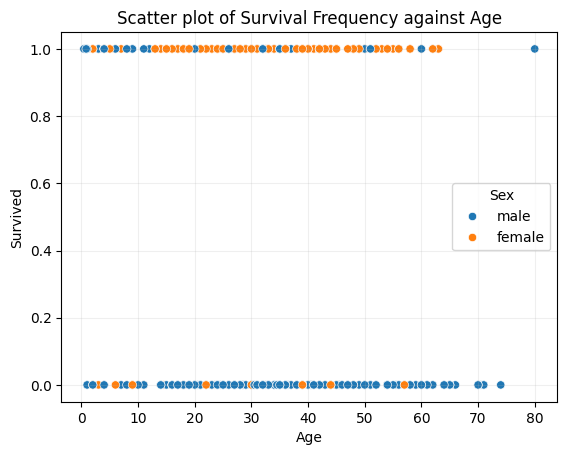

In [ ]:
sns.scatterplot(train_data,x='Age',y='Survived',hue='Sex')
plt.title("Scatter plot of Survival Frequency against Age")
plt.grid(True, which='major', linestyle='-',alpha=0.2)

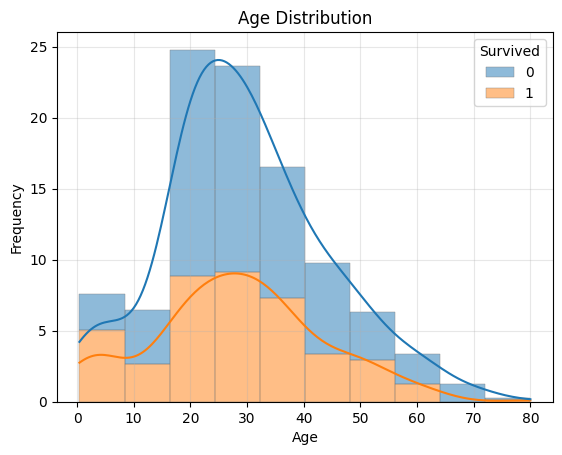

In [ ]:
sns.histplot(train_data, x='Age',hue='Survived', bins=10, kde=True,stat='percent', multiple="stack",linewidth=0.3,edgecolor='gray')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True,alpha=0.3)
plt.show()

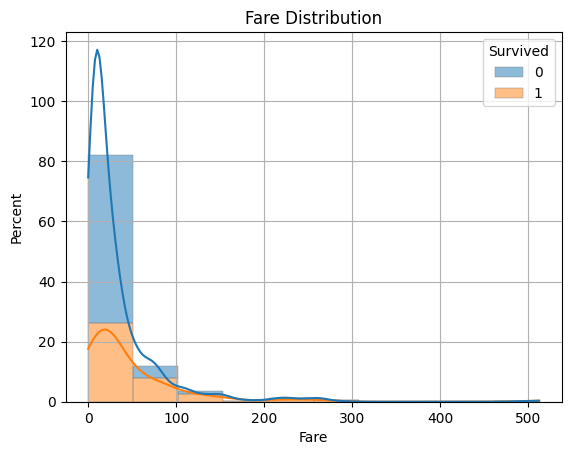

In [ ]:
sns.histplot(train_data, x='Fare',hue='Survived', bins=10, kde=True,stat='percent', multiple="stack",linewidth=0.3,edgecolor='gray')
plt.title("Fare Distribution")
plt.grid(True)
plt.show()

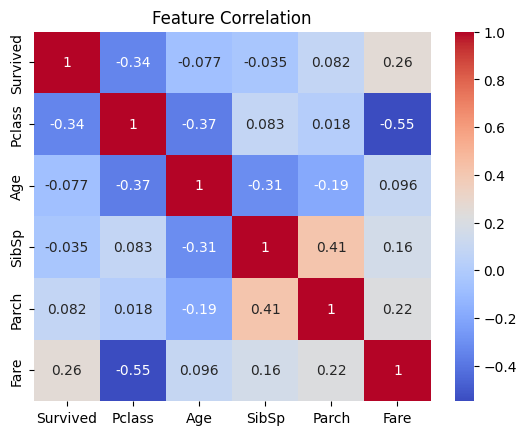

In [ ]:
corr = train_data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

## Training Model

In [ ]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

In [ ]:
model_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex',
                                                   'Embarked'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

In [ ]:
from sklearn.metrics import accuracy_score
y_pred=model_pipeline.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred))

Validation Accuracy: 0.7921348314606742


In [ ]:
from sklearn.neural_network import MLPClassifier
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(solver='lbfgs', alpha=1e-5,
                    hidden_layer_sizes=(5, 2), random_state=1))
])
model_pipeline.fit(X_train, y_train)
y_pred=model_pipeline.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred))

Validation Accuracy: 0.7921348314606742


In [ ]:
from sklearn import tree
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',tree.DecisionTreeClassifier())
])
model_pipeline.fit(X_train, y_train)
y_pred=model_pipeline.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred))

Validation Accuracy: 0.7696629213483146


In [ ]:
from sklearn.linear_model import SGDClassifier
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',SGDClassifier())
])
model_pipeline.fit(X_train, y_train)
y_pred=model_pipeline.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred))

Validation Accuracy: 0.7415730337078652


In [ ]:
from sklearn import svm
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',svm.SVC()
)
])
model_pipeline.fit(X_train, y_train)
y_pred=model_pipeline.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred))

Validation Accuracy: 0.7921348314606742


In [ ]:
features

['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Sex', 'Embarked']

In [ ]:
X_test=test_data[features]

In [ ]:
preds=model_pipeline.predict(X_test)
preds

array([0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': preds
})
submission.to_csv('submission.csv', index=False)

In [ ]:
submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [ ]:
sub

In [ ]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
